# ruleofthumb — text quickstart

Hello-world example on **dummy data**: explain a black-box text classifier
that consumes token embeddings.

Inputs are rectangular `(N, tokens, embedding)` float arrays. Padding is
explicit since v0.2: pass a validity mask or per-sample `lengths` — any pad
value works because the mask, not the data, carries the truth.

In [1]:
import numpy as np

from ruleofthumb.text import pad_sequences

rng = np.random.RandomState(0)
embedding_dim = 16
true_lengths = rng.randint(4, 13, size=64)  # variable real lengths

sequences = [rng.randn(t, embedding_dim).astype(np.float32) for t in true_lengths]
x, lengths = pad_sequences(sequences)        # x: (64, 12, 16), zero-padded

# Stand-in for the black-box LLM's predictions (e.g. sentiment labels).
y_outputs = np.asarray([1.0 if s[0, 0] > 0 else 0.0 for s in sequences], dtype=np.int64)
print(x.shape, lengths.tolist()[:8], y_outputs.shape)

torch.Size([64, 12, 16]) [9, 4, 7, 7, 11, 7, 9, 6] (64,)


In [2]:
import ruleofthumb

rot = ruleofthumb.fit_text(y_outputs=y_outputs, x_inputs=x.numpy(), epochs=30,
                           batch_size=32, learning_rate=0.01, lengths=lengths)

In [3]:
token_importances = rot.get_explanation(x.numpy(), lengths=lengths)  # shape [N, max_tokens]
print("explanations:", token_importances.shape)

# Padded tokens must score exactly zero:
i = 0
print(f"sample {i}: true length {true_lengths[i]}, padded tail all zero:",
      bool(np.all(token_importances[i, true_lengths[i]:] == 0)))
top_tokens = np.argsort(token_importances[i])[::-1][:3]
print(f"sample {i} most important tokens:", top_tokens.tolist())

explanations: (64, 12)
sample 0: true length 9, padded tail all zero: True
sample 0 most important tokens: [0, 8, 6]


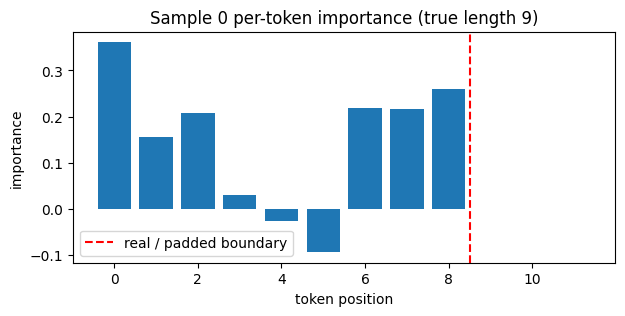

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
plt.bar(range(x.shape[1]), token_importances[0])
plt.axvline(true_lengths[0] - 0.5, color="red", linestyle="--", label="real / padded boundary")
plt.xlabel("token position")
plt.ylabel("importance")
plt.title(f"Sample 0 per-token importance (true length {true_lengths[0]})")
plt.legend()
plt.show()